# Member 4 — Herath H.M.H.D.P.
IT25100252 · OutlierHandling

This notebook demonstrates this member’s technique using the shared integrated recipe. Run `group_pipeline.ipynb` for every stage and final exports.

## 01 · Load and inspect the assigned diabetes data

Eight input fields plus target `diabetes`. The reference Framingham columns are not copied.

In [1]:
from pathlib import Path
import sys, os
# In Colab: upload/extract the COMPLETE corrected project ZIP first.
# If needed set PROJECT_ROOT = Path('/content/MLB-B9G2-06').
PROJECT_ROOT = next((p for base in [Path.cwd(), *Path.cwd().parents, Path('/content')]
                     for p in [base, base/'MLB-B9G2-06']
                     if (p/'src/project_core.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Extract the complete project ZIP and set PROJECT_ROOT above.')
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from project_core import *
from IPython.display import display
from threadpoolctl import threadpool_limits
thread_limit = threadpool_limits(limits=2)
raw, clean, X_train, X_test, y_train, y_test = load_dataset(PROJECT_ROOT)
print('Raw / clean / train / test:', len(raw), len(clean), len(X_train), len(X_test))

display(raw.head())
display(raw.dtypes.to_frame("dtype"))
display(raw.describe(include="all").T)

Raw / clean / train / test: 100000 96146 76916 19230


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


,dtype
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


## 06 · Member 1 — fit imputations on training only

Numerical median and categorical/binary mode are learned on training rows. They are safety handling for future missing inputs, not a claim that this CSV contained nulls.

In [2]:
preprocessor=make_preprocessor('engineered_bmi_capped')
preprocessor.fit(X_train)
prep=preprocessor.named_steps['prepare']
imputed=prep.impute(X_train)
display(prep.medians_.to_frame('training_median'))
print('Modes:',prep.modes_)
assert imputed.isna().sum().sum()==0
imputed.to_csv(PROJECT_ROOT/'results/outputs/02_train_imputed.csv',index_label='raw_row_id')

Modes: {'gender': 'Female', 'smoking_history': 'never', 'hypertension': np.int64(0), 'heart_disease': np.int64(0)}


,training_median
age,43.00
bmi,27.32
HbA1c_level,5.80
blood_glucose_level,140.00


## 07 · Member 4 — inspect all continuous outliers; compare BMI capping

An IQR outlier is not automatically an error. Keep glucose and HbA1c signal. Only the enhanced candidate caps BMI using training bounds; the original-feature candidate keeps BMI too. BMI capping is a hypothesis under evaluation, not a clinically validated rule.

BMI training bounds: 13.7 39.540000000000006
BMI flags before: 4244
BMI flags after, SAME bounds: 0


,feature,q1,q3,lower,upper,flagged_train_rows,action
0,age,24.00,59.00,-28.5,111.50,0,retain values; do not treat IQR flag as error
1,bmi,23.39,29.85,13.7,39.54,4244,compare optional BMI capping
2,HbA1c_level,4.80,6.20,2.7,8.30,1041,retain values; do not treat IQR flag as error
3,blood_glucose_level,100.00,159.00,11.5,247.50,1598,retain values; do not treat IQR flag as error


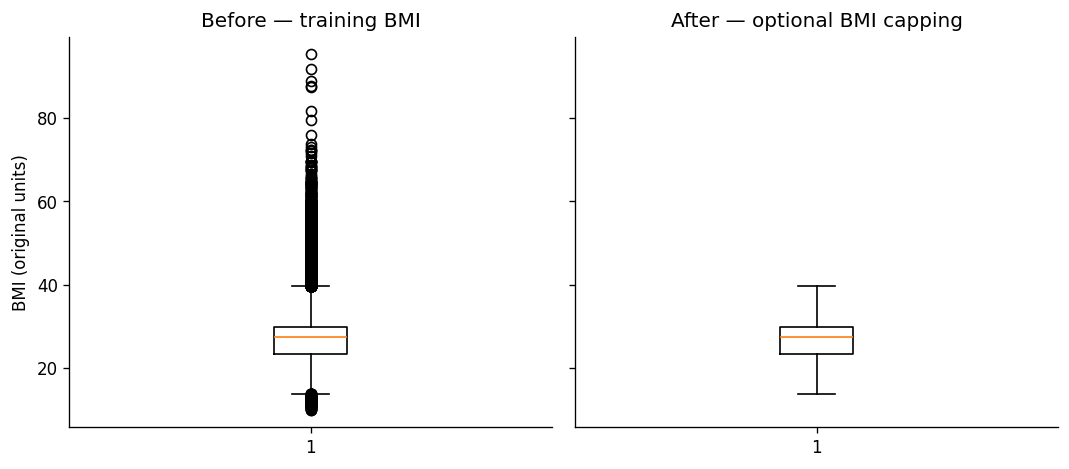

In [3]:
audit=outlier_audit(X_train);display(audit)
audit.to_csv(PROJECT_ROOT/'results/outputs/outlier_audit.csv',index=False)
capped=prep.cap(imputed)
lo,hi=prep.bmi_bounds_
print('BMI training bounds:',lo,hi)
print('BMI flags before:',int(((imputed.bmi<lo)|(imputed.bmi>hi)).sum()))
print('BMI flags after, SAME bounds:',int(((capped.bmi<lo)|(capped.bmi>hi)).sum()))
assert np.array_equal(capped.HbA1c_level,imputed.HbA1c_level)
assert np.array_equal(capped.blood_glucose_level,imputed.blood_glucose_level)
fig,axes=plt.subplots(1,2,figsize=(9,4),sharey=True)
axes[0].boxplot(imputed.bmi);axes[1].boxplot(capped.bmi)
axes[0].set_title('Before — training BMI');axes[1].set_title('After — optional BMI capping');axes[0].set_ylabel('BMI (original units)')
savefig(PROJECT_ROOT,'04_bmi_before_after')
capped.to_csv(PROJECT_ROOT/'results/outputs/03_train_bmi_handled.csv',index_label='raw_row_id')